Dataset loaded! Shape: (100000, 7)
Columns after dropping IDs: ['Amount', 'MerchantID', 'TransactionType', 'Location', 'IsFraud']

Encoding categorical columns: ['TransactionType', 'Location']
All columns are now numeric ✅

Duplicate rows: 0

Class Distribution:
IsFraud
0    99000
1     1000
Name: count, dtype: int64
Fraud %: 1.00%


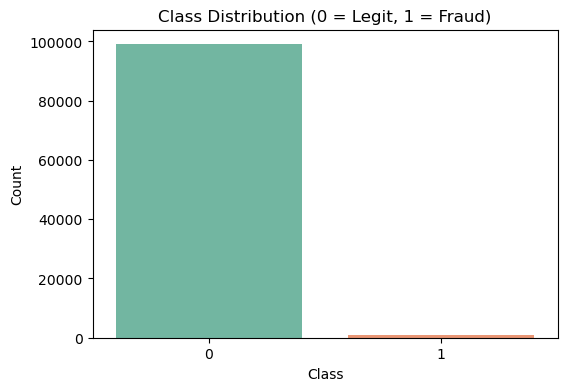

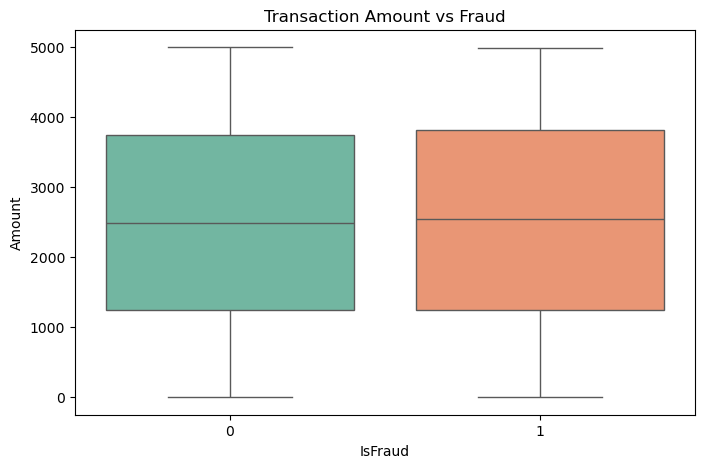

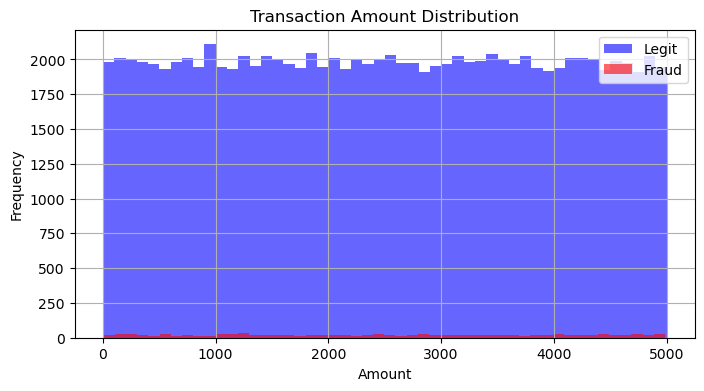

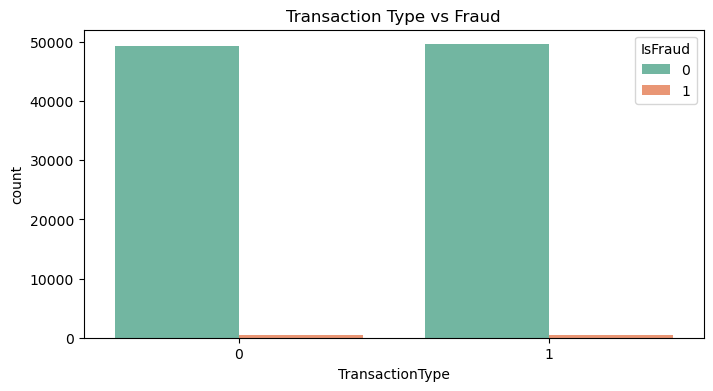

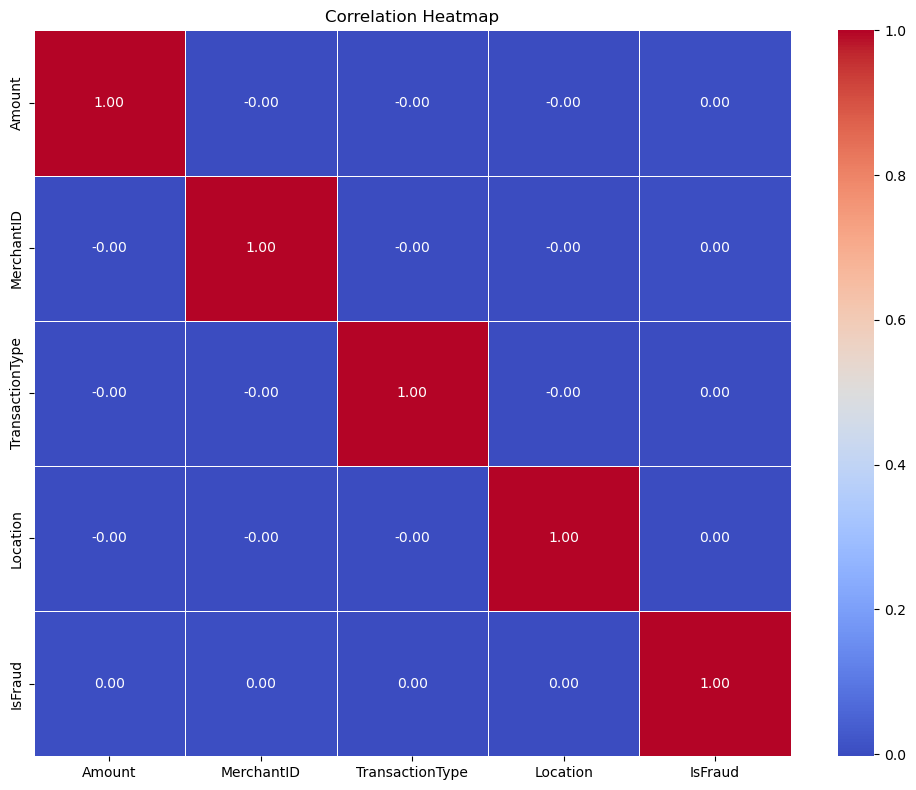

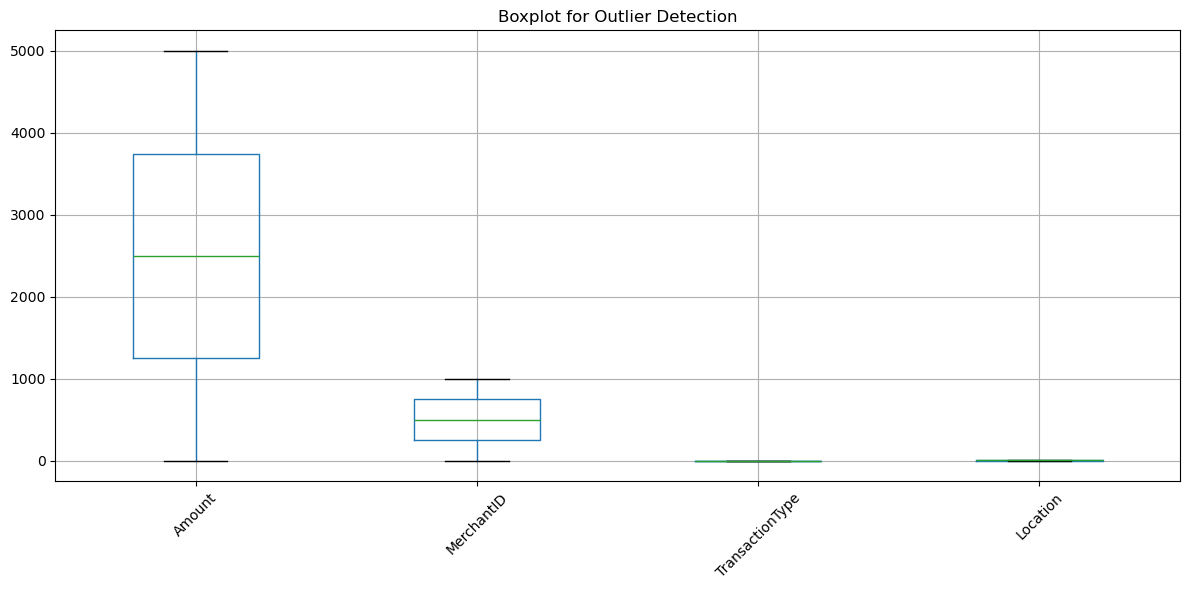

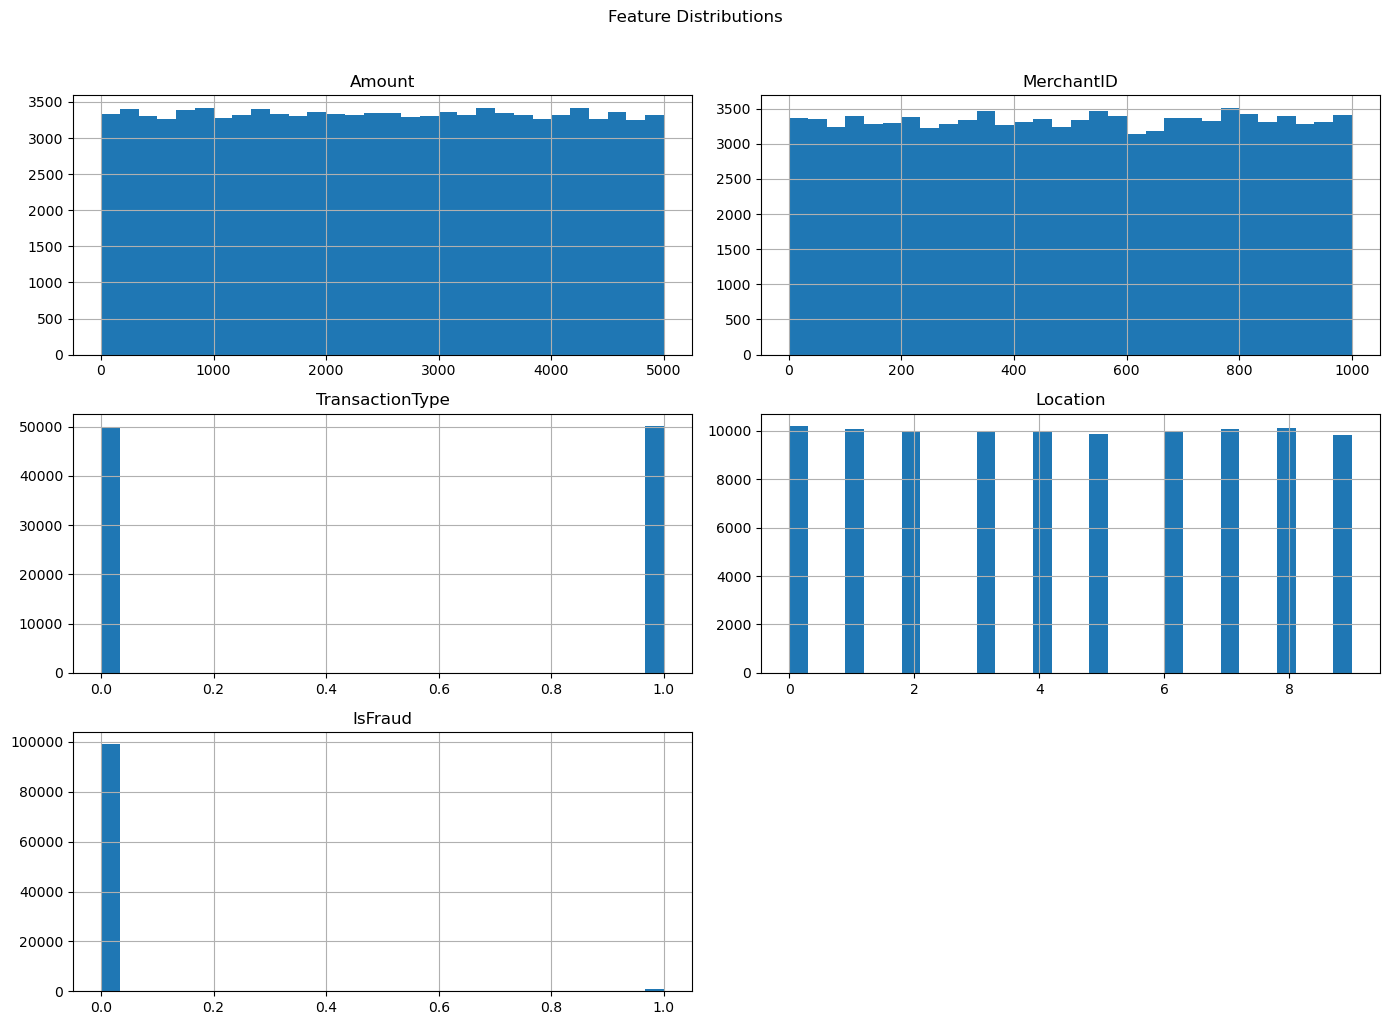


Training set: {0: 79200, 1: 800}
Test set: {0: 19800, 1: 200}

Class weight ratio (Legit:Fraud) = 99:1

Random Forest Accuracy: 0.98995

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99     19800
       Fraud       0.00      0.00      0.00       200

    accuracy                           0.99     20000
   macro avg       0.49      0.50      0.50     20000
weighted avg       0.98      0.99      0.99     20000



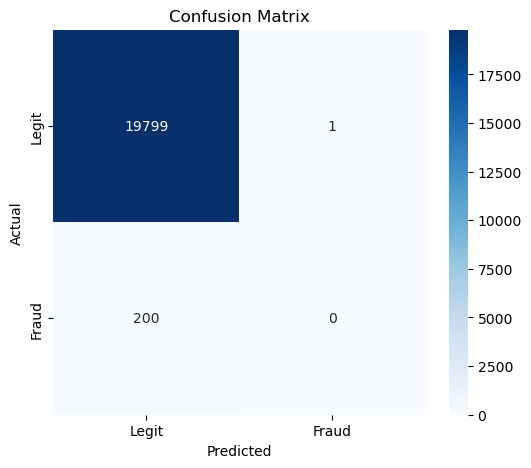

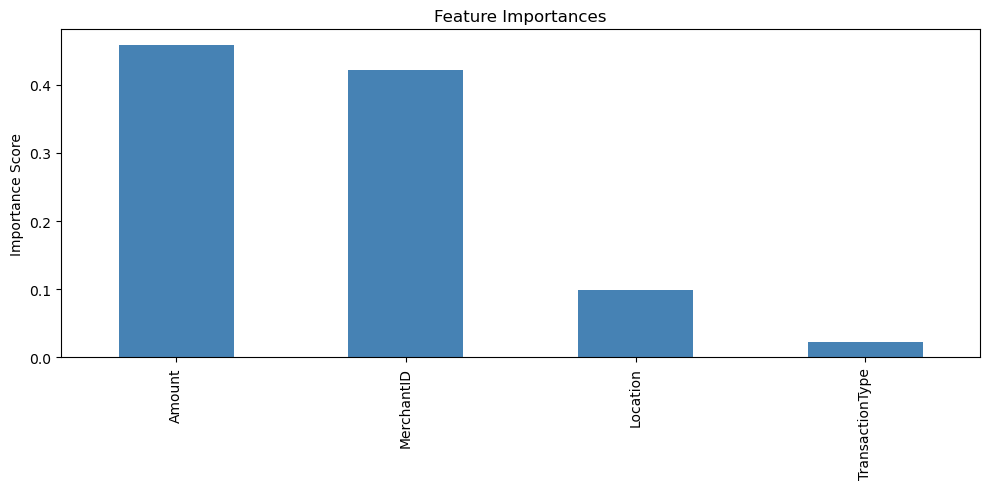


Model saved successfully!

Sample Prediction: Legit
Actual Label:      Legit

ROC-AUC Score: 0.5019358585858587

✅ Pipeline Created & Trained

✅ Full system saved (model + scaler + encoders + pipeline)


NameError: name 'np' is not defined

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import pickle
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ─────────────────────────────────────────────
# 1. LOAD DATASET
# ─────────────────────────────────────────────
df = pd.read_csv(r'C:\Users\Sakshi\Documents\credit_card_fraud_dataset.csv')
print("Dataset loaded! Shape:", df.shape)

# ─────────────────────────────────────────────
# 2. DROP USELESS COLUMNS (IDs & timestamps only)
# ─────────────────────────────────────────────
drop_cols = ['TransactionID', 'TransactionDate']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
print("Columns after dropping IDs:", df.columns.tolist())

# ─────────────────────────────────────────────
# 3. ENCODE CATEGORICAL COLUMNS
#    (TransactionType, Location → numbers)
# ─────────────────────────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"\nEncoding categorical columns: {cat_cols}")

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

joblib.dump(encoders, "encoders.joblib")

print("All columns are now numeric ✅")

# ─────────────────────────────────────────────
# 4. MISSING VALUES
# ─────────────────────────────────────────────
df = df.fillna(df.median(numeric_only=True))

# ─────────────────────────────────────────────
# 5. DUPLICATE CHECK
# ─────────────────────────────────────────────
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

# ─────────────────────────────────────────────
# 6. TARGET COLUMN
# ─────────────────────────────────────────────
target_col = 'IsFraud'
print(f"\nClass Distribution:")
print(df[target_col].value_counts())
print(f"Fraud %: {df[target_col].mean() * 100:.2f}%")

# ─────────────────────────────────────────────
# 7. EDA - VISUALIZATIONS
# ─────────────────────────────────────────────

# Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df, hue=target_col, palette='Set2', legend=False)
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Amount by Class
plt.figure(figsize=(8, 5))
sns.boxplot(x=target_col, y='Amount', data=df, hue=target_col, palette='Set2', legend=False)
plt.title("Transaction Amount vs Fraud")
plt.show()

# Amount distribution overlay
plt.figure(figsize=(8, 4))
df[df[target_col] == 0]['Amount'].hist(bins=50, alpha=0.6, label='Legit', color='blue')
df[df[target_col] == 1]['Amount'].hist(bins=50, alpha=0.6, label='Fraud', color='red')
plt.legend()
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# TransactionType vs Fraud
plt.figure(figsize=(8, 4))
sns.countplot(x='TransactionType', hue=target_col, data=df, palette='Set2')
plt.title("Transaction Type vs Fraud")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Boxplot for Outlier Detection
plt.figure(figsize=(12, 6))
df.drop(columns=[target_col]).boxplot()
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Histograms
df.hist(figsize=(14, 10), bins=30)
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 8. FEATURE ENGINEERING & SCALING
# ─────────────────────────────────────────────
X = df.drop(target_col, axis=1)
y = df[target_col]

scaler = StandardScaler()
X[['Amount']] = scaler.fit_transform(X[['Amount']])

# ─────────────────────────────────────────────
# 9. TRAIN-TEST SPLIT
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTraining set:", y_train.value_counts().to_dict())
print("Test set:", y_test.value_counts().to_dict())

# ─────────────────────────────────────────────
# 10. TRAIN RANDOM FOREST
#     scale_pos_weight handles 99:1 imbalance
# ─────────────────────────────────────────────
fraud_ratio = int((y_train == 0).sum() / (y_train == 1).sum())
print(f"\nClass weight ratio (Legit:Fraud) = {fraud_ratio}:1")

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight={0: 1, 1: fraud_ratio}   # heavily penalizes missing fraud
)
rf.fit(X_train, y_train)

# ─────────────────────────────────────────────
# 11. EVALUATION
# ─────────────────────────────────────────────
y_pred = rf.predict(X_test)

print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                             target_names=['Legit', 'Fraud'],
                             zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue')
plt.title("Feature Importances")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 12. SAVE MODEL & SCALER
# ─────────────────────────────────────────────
joblib.dump(rf, "random_forest_fraud_model.joblib")
joblib.dump(scaler, "scaler_fraud.joblib")

with open("random_forest_fraud_model.pkl", "wb") as f:
    pickle.dump(rf, f)

print("\nModel saved successfully!")

# ─────────────────────────────────────────────
# 13. PREDICT ON A NEW TRANSACTION
# ─────────────────────────────────────────────
model = joblib.load("random_forest_fraud_model.joblib")

sample = X_test.iloc[[0]]
prediction = model.predict(sample)
actual = y_test.iloc[0]

print(f"\nSample Prediction: {'Fraud' if prediction[0] == 1 else 'Legit'}")
print(f"Actual Label:      {'Fraud' if actual == 1 else 'Legit'}")
#-----------------------------------------------------------
#14. ROC-AUC SCORE (ADD THIS)

from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:, 1]

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))
# 15. CREATE PIPELINE (MODEL + SCALER)


from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=50,
        random_state=42,
        n_jobs=-1,
        class_weight={0: 1, 1: fraud_ratio}
    ))
])

pipeline.fit(X_train, y_train)

print("\n✅ Pipeline Created & Trained")
# SAVE COMPLETE SYSTEM (IMPORTANT)

joblib.dump({
    "model": rf,
    "scaler": scaler,
    "pipeline": pipeline,
    "encoders": encoders,
    "features": X.columns.tolist()
}, "fraud_full_system.joblib")

with open("fraud_full_system.pkl", "wb") as f:
    pickle.dump({
        "model": rf,
        "scaler": scaler,
        "pipeline": pipeline,
        "encoders": encoders,
        "features": X.columns.tolist()
    }, f)

print("\n✅ Full system saved (model + scaler + encoders + pipeline)")
#🔥 17. LOAD FULL SYSTEM (SAFE)

loaded = joblib.load("fraud_full_system.joblib")

loaded_pipeline = loaded["pipeline"]
loaded_features = loaded["features"]
# 18. SAFE REAL-WORLD PREDICTION

# Create empty input
# Create empty input
# Create realistic sample input (same structure as training data)
new_sample = pd.DataFrame([X_test.iloc[0].values], columns=loaded_features)

# Predict
pred = loaded_pipeline.predict(new_sample)

print("\n🔹 New Transaction Prediction:",
      "Fraud" if pred[0] == 1 else "Legit")
